## Redes Neuronales Convolucionales con PyTorch - Early Stopping

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import sampler
import torchvision.datasets as datasets
import torchvision.transforms as T
import matplotlib.pyplot as plt

In [6]:
def plot_history(history, figsize=(12, 4), title_suffix=''):
    required_keys = ['train_loss', 'val_loss', 'train_acc', 'val_acc']
    for key in required_keys:
        if key not in history:
            raise KeyError(f"Falta la llave '{key}' en history")

    epochs_range = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=figsize)

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='train_loss')
    plt.plot(epochs_range, history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f"Loss por época {title_suffix}".strip())
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='train_acc')
    plt.plot(epochs_range, history['val_acc'], label='val_acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f"Accuracy por época {title_suffix}".strip())
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Descargar Cifar10 dataset

In [7]:
DATA_PATH = '../data/Databases/cifar-10-batches-py'
NUM_TRAIN = 50000
NUM_VAL = 5000
NUM_TEST = 5000
MINIBATCH_SIZE = 64

transform_cifar = T.Compose([
                T.ToTensor(),
                T.Normalize([0.491, 0.482, 0.447], [0.247, 0.243, 0.261])
            ])

# Train dataset
cifar10_train = datasets.CIFAR10(DATA_PATH, train=True, download=True,
                             transform=transform_cifar)
train_loader = DataLoader(cifar10_train, batch_size=MINIBATCH_SIZE, 
                          sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN)))
#Validation set
cifar10_val = datasets.CIFAR10(DATA_PATH, train=False, download=True,
                           transform=transform_cifar)
val_loader = DataLoader(cifar10_val, batch_size=MINIBATCH_SIZE, 
                        sampler=sampler.SubsetRandomSampler(range(NUM_VAL)))
#Test set
cifar10_test = datasets.CIFAR10(DATA_PATH, train=False, download=True, 
                            transform=transform_cifar)
test_loader = DataLoader(cifar10_test, batch_size=MINIBATCH_SIZE,
                        sampler=sampler.SubsetRandomSampler(range(NUM_VAL, NUM_VAL + NUM_TEST)))

c:\Users\jose.rodriguezb\Desktop\Proyecto-I-Clasificador-Imagenes\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [8]:
cifar10_train

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ../data/Databases/cifar-10-batches-py
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.491, 0.482, 0.447], std=[0.247, 0.243, 0.261])
           )

### Usar GPUs

In [9]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(device)

cuda


### Mostrar imágenes

La imagen muestreada representa un: cat


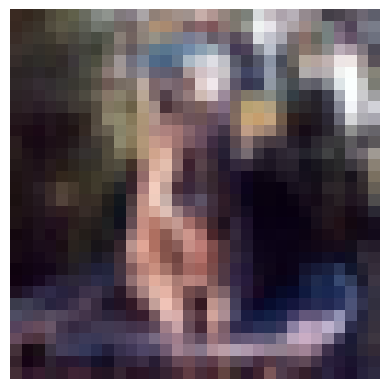

In [10]:
classes = test_loader.dataset.classes
def plot_figure(image):
    plt.imshow(np.transpose(image,(1,2,0)))
    plt.axis('off')
    plt.show()

rnd_sample_idx = np.random.randint(len(test_loader))
print(f'La imagen muestreada representa un: {classes[test_loader.dataset[rnd_sample_idx][1]]}')
image = test_loader.dataset[rnd_sample_idx][0]
image = (image - image.min()) / (image.max() -image.min() )
plot_figure(image)


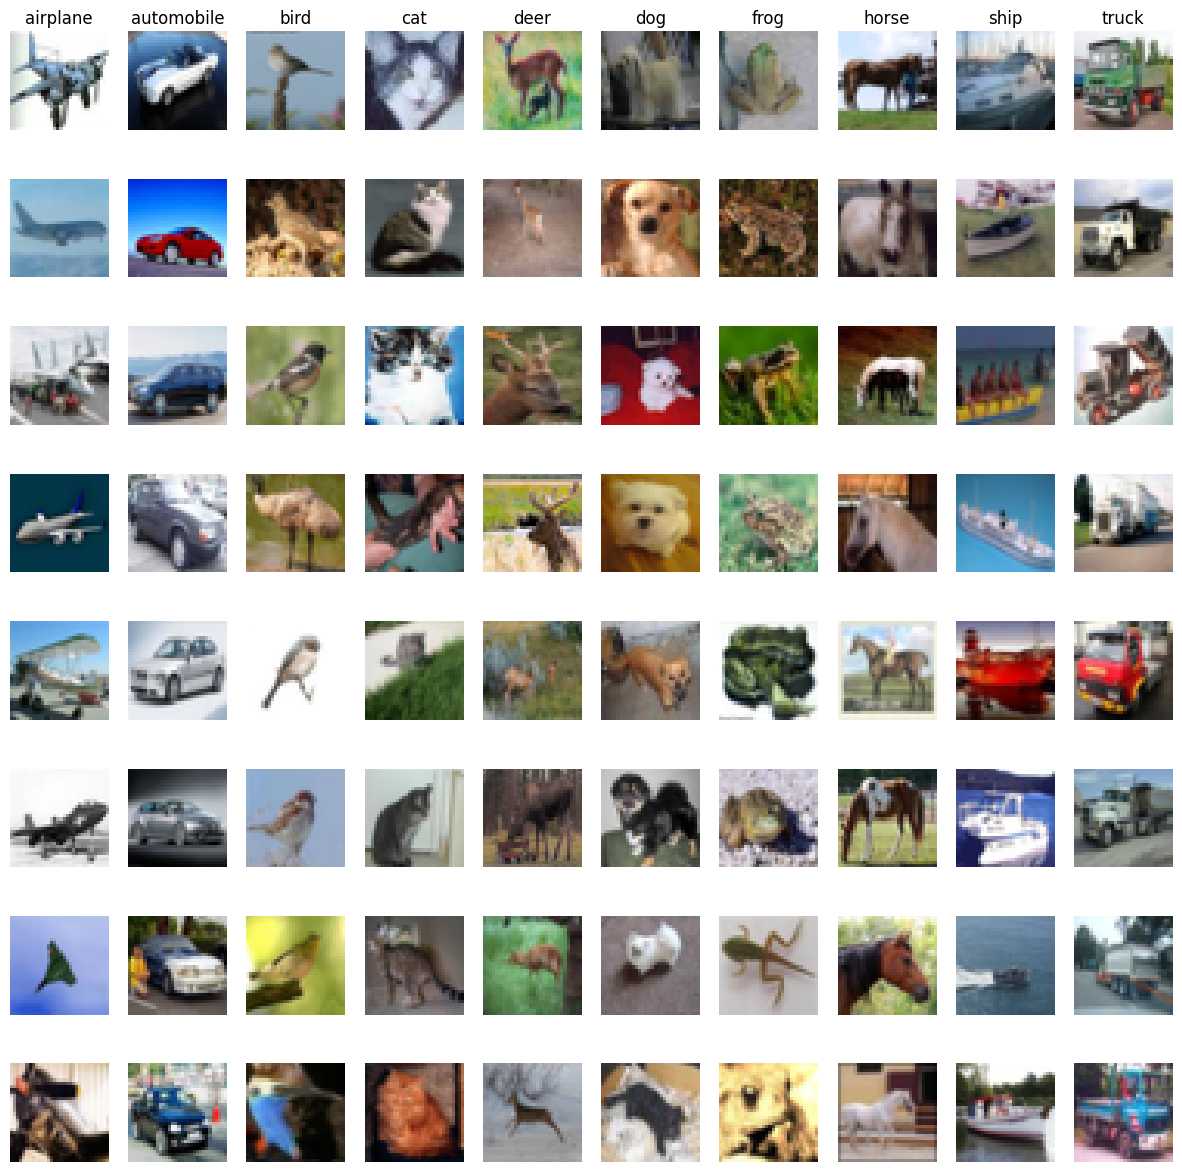

In [11]:
def plot_cifar10_grid():
    classes = test_loader.dataset.classes
    total_samples = 8
    plt.figure(figsize=(15,15))
    for label, sample in enumerate(classes):
        class_idxs = np.flatnonzero(label == np.array(test_loader.dataset.targets))
        sample_idxs = np.random.choice(class_idxs, total_samples, replace = False)
        for i, idx in enumerate(sample_idxs):
            plt_idx = i*len(classes) + label + 1
            plt.subplot(total_samples, len(classes), plt_idx)
            plt.imshow(test_loader.dataset.data[idx])
            plt.axis('off')
            
            if i == 0: plt.title(sample)
    plt.show()

plot_cifar10_grid() 

### Calcular accuracy y loss


In [12]:
def evaluate(model, loader):
    num_correct = 0
    num_total = 0
    total_loss = 0.0
    model.eval()
    model = model.to(device=device)
    with torch.no_grad():
        for xi, yi in loader:
            xi = xi.to(device=device, dtype=torch.float32)
            yi = yi.to(device=device, dtype=torch.long)
            scores = model(xi)
            loss = F.cross_entropy(scores, yi)
            _, pred = scores.max(dim=1)
            num_correct += (pred == yi).sum().item()
            num_total += yi.size(0)
            total_loss += loss.item() * yi.size(0)
    acc = num_correct / num_total
    avg_loss = total_loss / num_total
    return acc, avg_loss

### Early Stopping

In [13]:
import numpy as np
import torch

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, path='../models/checkpoint_cifar10.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        # Guarda el estado del modelo cuando el loss de validación mejora
        torch.save(model.state_dict(), self.path)

### Loop de entrenamiento

In [14]:
def train(model, optimiser, early_stopper=None, epochs=100):
    model = model.to(device=device)
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    for epoch in range(epochs):
        model.train() # Mover fuera del loop de batches por eficiencia
        for i, (xi, yi) in enumerate(train_loader):
            xi = xi.to(device=device, dtype=torch.float32)
            yi = yi.to(device=device, dtype=torch.long)
            
            scores = model(xi)
            cost = F.cross_entropy(input=scores, target=yi)

            optimiser.zero_grad()
            cost.backward()
            optimiser.step()

        # Evaluación al final de la época
        train_acc, train_loss = evaluate(model, train_loader)
        val_acc, val_loss = evaluate(model, val_loader)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(
            f"Epoch: {epoch+1}/{epochs} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.4f}"
        )

        # --- Lógica de Early Stopping ---
        if early_stopper is not None:
            early_stopper(val_loss, model)
            if early_stopper.early_stop:
                print(f"== Early stopping en la época {epoch+1} ==")
                # Cargamos los mejores pesos antes de retornar
                model.load_state_dict(torch.load(early_stopper.path))
                break

    return history

In [15]:
conv_k_3 = lambda channel1, channel2: nn.Conv2d(channel1, channel2, kernel_size=3, padding=1)

In [16]:
class CNN_class3(nn.Module):
    def __init__(self, in_channel, channel1, channel2):
        super().__init__()
        self.conv1 = conv_k_3(in_channel, channel1)
        self.bn1 = nn.BatchNorm2d(channel1, momentum=0.01)

        self.conv2 = conv_k_3(channel1, channel2)
        self.bn2 = nn.BatchNorm2d(channel2, momentum=0.01)
        
        self.max_pool = nn.MaxPool2d(2,2)
        

    def forward(self, x):
        x = F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x))))))
        return self.max_pool(x)

In [17]:
channel1 = 32
channel2 = 64
channel3 = 128
channel4 = 64
epochs = 20
lr = 0.001
modelCNN4 = nn.Sequential(
        CNN_class3(3,channel1, channel2),
        CNN_class3(channel2, channel4, channel4),
        
        nn.Flatten(),

        # Nueva Capa Densa Intermedia
        nn.Linear(in_features=8*8*channel4, out_features=128), # Capa oculta
        nn.ReLU(),                                             # Activación
        nn.Dropout(p=0.5),                                     # Regularización para 
                                                               # evitar overfitting

        # Capa de Clasificación Final
        nn.Linear(in_features=128, out_features=10)
)
optimiser = torch.optim.Adam(modelCNN4.parameters(), lr, weight_decay=1e-4)

Epoch: 1/100 | train_loss: 1.1435 | train_acc: 0.5889 | val_loss: 1.1542 | val_acc: 0.5900
Epoch: 2/100 | train_loss: 0.9323 | train_acc: 0.6584 | val_loss: 0.9556 | val_acc: 0.6570
Epoch: 3/100 | train_loss: 0.7864 | train_acc: 0.7261 | val_loss: 0.8522 | val_acc: 0.7054
Epoch: 4/100 | train_loss: 0.8121 | train_acc: 0.7195 | val_loss: 0.8882 | val_acc: 0.6976
EarlyStopping counter: 1 out of 5
Epoch: 5/100 | train_loss: 0.6647 | train_acc: 0.7710 | val_loss: 0.7566 | val_acc: 0.7494
Epoch: 6/100 | train_loss: 0.5977 | train_acc: 0.7888 | val_loss: 0.7109 | val_acc: 0.7512
Epoch: 7/100 | train_loss: 0.5534 | train_acc: 0.8070 | val_loss: 0.6909 | val_acc: 0.7622
Epoch: 8/100 | train_loss: 0.5724 | train_acc: 0.7981 | val_loss: 0.7143 | val_acc: 0.7504
EarlyStopping counter: 1 out of 5
Epoch: 9/100 | train_loss: 0.4801 | train_acc: 0.8330 | val_loss: 0.6417 | val_acc: 0.7820
Epoch: 10/100 | train_loss: 0.4695 | train_acc: 0.8343 | val_loss: 0.6662 | val_acc: 0.7760
EarlyStopping counter

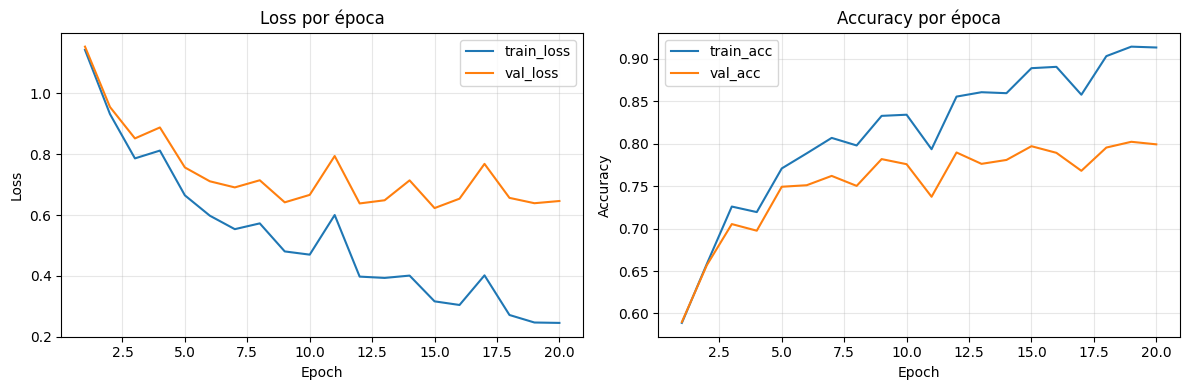

CPU times: total: 8min 9s
Wall time: 19min 34s


In [18]:
%%time
selector_parada = EarlyStopping(patience=5)
history = train(modelCNN4, optimiser, early_stopper=selector_parada, epochs=100)
plot_history(history)

In [20]:
test_acc, _ = evaluate(modelCNN4, test_loader)
print(f'test_acc: {test_acc:.4f}')

test_acc: 0.8036


## Sin early stopping

In [27]:
channel1 = 32
channel2 = 64
channel3 = 128
channel4 = 64
lr = 0.001
modelCNN5 = nn.Sequential(
        CNN_class3(3,channel1, channel2),
        CNN_class3(channel2, channel4, channel4),
        
        nn.Flatten(),

        # Nueva Capa Densa Intermedia
        nn.Linear(in_features=8*8*channel4, out_features=128), # Capa oculta
        nn.ReLU(),                                             # Activación
        nn.Dropout(p=0.5),                                     # Regularización para 
                                                               # evitar overfitting

        # Capa de Clasificación Final
        nn.Linear(in_features=128, out_features=10)
)
optimiser = torch.optim.Adam(modelCNN5.parameters(), lr, weight_decay=1e-4)

Epoch: 1/100 | train_loss: 1.1014 | train_acc: 0.6080 | val_loss: 1.1261 | val_acc: 0.6016
Epoch: 2/100 | train_loss: 0.9155 | train_acc: 0.6808 | val_loss: 0.9461 | val_acc: 0.6686
Epoch: 3/100 | train_loss: 0.8447 | train_acc: 0.7004 | val_loss: 0.8861 | val_acc: 0.6932
Epoch: 4/100 | train_loss: 0.6922 | train_acc: 0.7620 | val_loss: 0.7629 | val_acc: 0.7400
Epoch: 5/100 | train_loss: 0.6490 | train_acc: 0.7797 | val_loss: 0.7313 | val_acc: 0.7500
Epoch: 6/100 | train_loss: 0.6673 | train_acc: 0.7690 | val_loss: 0.7677 | val_acc: 0.7400
Epoch: 7/100 | train_loss: 0.6211 | train_acc: 0.7881 | val_loss: 0.7407 | val_acc: 0.7476
Epoch: 8/100 | train_loss: 0.5705 | train_acc: 0.7976 | val_loss: 0.7109 | val_acc: 0.7580
Epoch: 9/100 | train_loss: 0.6034 | train_acc: 0.7882 | val_loss: 0.7522 | val_acc: 0.7450
Epoch: 10/100 | train_loss: 0.4613 | train_acc: 0.8387 | val_loss: 0.6330 | val_acc: 0.7822
Epoch: 11/100 | train_loss: 0.4122 | train_acc: 0.8569 | val_loss: 0.6241 | val_acc: 0.79

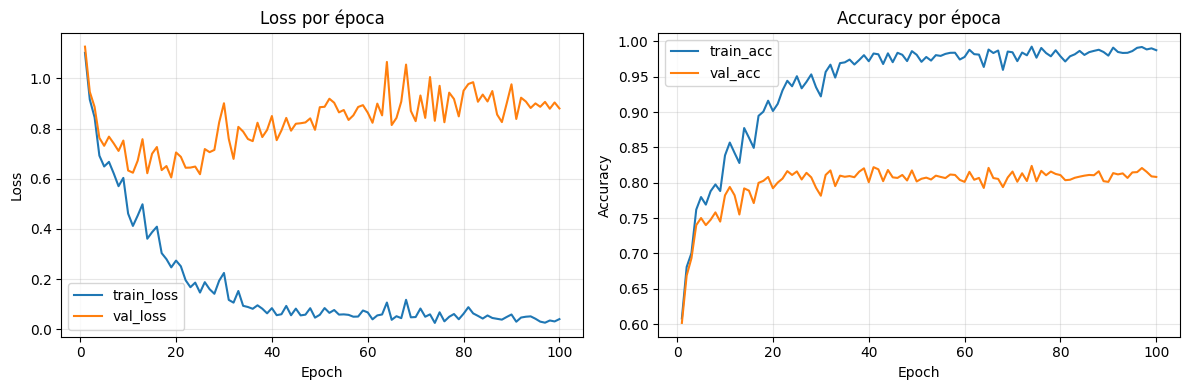

CPU times: total: 41min 52s
Wall time: 2h 26min 14s


In [28]:
%%time
history = train(modelCNN5, optimiser,  epochs=100)
plot_history(history)

In [29]:
test_acc, _ = evaluate(modelCNN5, test_loader)
print(f'test_acc: {test_acc:.4f}')

test_acc: 0.8042
